#  Feature Scaling

Scaling features in the context of machine learning refers to the process of transforming your input variables (features) so that they all have the same scale or range. It ensures that different features contribute equally to a machine learning model.

Many machine learning algorithms perform better when numerical features are on a similar scale because they rely on distances, gradients, or assumptions about the data distribution.

# Why Do We Need Feature Scaling?

Imagine a dataset with two features:

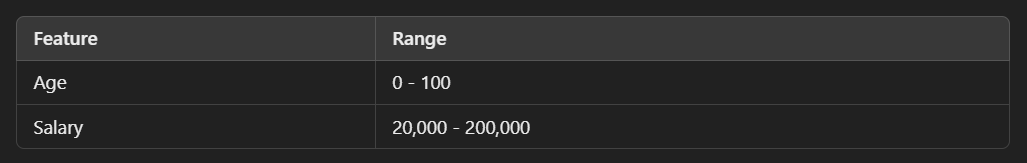

Since salary has a much larger range than age, it might dominate the model’s learning process, leading to biased results.

**Feature scaling helps:** 
- ✅ Prevent features with larger magnitudes from overpowering others.
- ✅ Improve the convergence speed of gradient-based algorithms (e.g., Gradient Descent).
- ✅ Improve accuracy for distance-based models (e.g., KNN, SVM, k-Means).
- ✅ Make data more suitable for models requiring normal distribution (e.g., PCA).

# Why Scaling Features is Necessary:

**Different Scales:** Features in your dataset may have different units of measurement or different scales. For example, one feature might measure weight in kilograms, while another measures height in meters. These different scales can cause some machine learning algorithms to perform poorly because they may give too much importance to features with larger scales.

**Gradient Descent:** Many machine learning algorithms, especially those based on gradient descent (e.g., linear regression, neural networks), converge faster when features are on similar scales. If features have significantly different scales, the gradient descent process can be skewed, leading to longer convergence times or convergence to suboptimal solutions.

**Distance-Based Algorithms:** Algorithms that rely on distances between data points, such as k-means clustering or support vector machines, can be sensitive to feature scales. Features with larger scales might dominate the distance calculations, leading to biased results.

**Regularization:** Regularization techniques, like L1 and L2 regularization, can be sensitive to feature scales. In some cases, regularization might unfairly penalize features with larger scales.

# When Do We Use Feature Scaling?

**Feature scaling is necessary for:****

    - Gradient-based algorithms (e.g., Linear Regression, Logistic Regression, Neural Networks).
    - Distance-based algorithms (e.g., KNN, SVM, k-Means).
    - Principal Component Analysis (PCA) (since it relies on variance, which is scale-sensitive).

**Feature scaling is not required for:**

    - Tree-based algorithms (e.g., Decision Trees, Random Forest, XGBoost) since they are not distance-based.

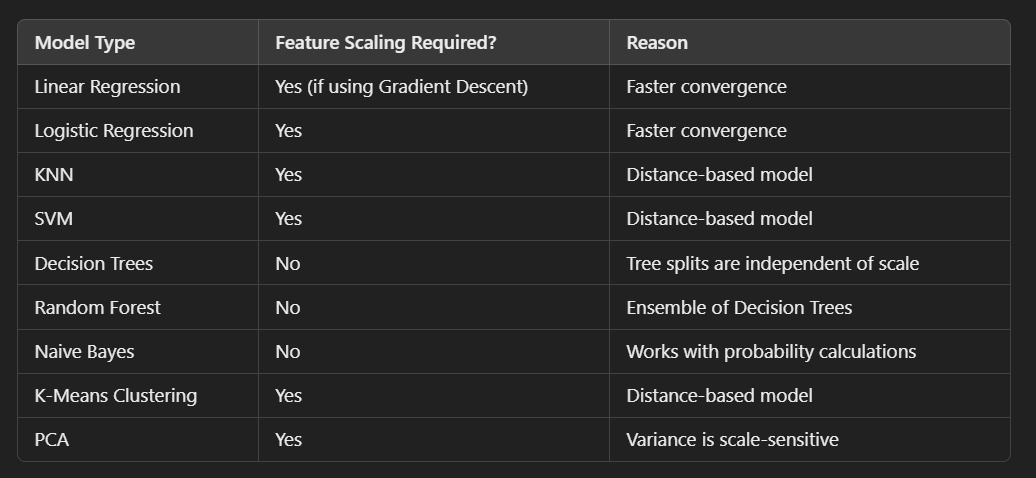

# Feature Scaling techniques

There are several common methods for scaling features:

## Min-Max Scaling (Normalization) 

This method scales features to a specific range, usually [0, 1]. It subtracts the minimum value of the feature from each data point and then divides by the range (the difference between the maximum and minimum values). 
- Scales features to a fixed range, typically [0,1].
- Min-max scaling preserves the relative relationships between data points.
- Used when data has a fixed range and no outliers.
- **Best for:** Algorithms that assume bounded data or distance-based models like k-NN, SVM, and neural networks.
    
**Formula for Min-Max Scaling:** `X_scaled = (X - X_min) / (X_max - X_min)`



## Standardization (Z-score Normalization) 

Standardization transforms features to have a mean of 0 and a standard deviation of 1. It subtracts the mean of the feature from each data point and then divides by the standard deviation.

- Centers the data around 0 with a standard deviation of 1.
- Standardization is less sensitive to outliers compared to min-max scaling.
- **Best for:** Data with outliers or when the distribution is normal. Commonly used in logistic regression, linear regression, and SVM.
    
**Formula for Standardization:** `X_scaled = (X - X_mean) / X_std`



## Robust Scaling 
This method is similar to standardization but uses the median and the interquartile range (IQR) instead of the mean and standard deviation. It's less sensitive to outliers because it relies on the median and IQR, which are robust to extreme values.
- Used when data has outliers.

**Formula for Robust Scaling:** `X_scaled = (X - X_median) / IQR`

The choice of scaling method depends on your specific dataset and the requirements of your machine learning algorithm. It's common practice to try different scaling methods and evaluate their impact on your model's performance. 

Some algorithms, like **decision trees and random forests, are not sensitive to feature scales and may not require feature scaling**. However, for many other algorithms, scaling features is an important preprocessing step to improve model performance.

In [11]:
# lets say we have X feature

X=[[1,2,3]]

**It's common practice to try different scaling methods and evaluate their impact on your model's performance.**

In [12]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_X = scaler.fit_transform(X)
scaled_X

array([[0., 0., 0.]])

In [13]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
standardized_X = scaler.fit_transform(X)
standardized_X

array([[0., 0., 0.]])

In [15]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()
scaled_X = scaler.fit_transform(X)
scaled_X

array([[0., 0., 0.]])

**To train a model and make predictions on the given DataFrame while performing feature scaling, you can follow these steps. We'll use Python with scikit-learn for this task:**

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load the dataset
data = pd.DataFrame({
    'Car': ['Toyota', 'Mitsubishi', 'Skoda', 'Fiat', 'Mini', 'VW', 'Skoda', 'Mercedes', 'Ford', 'Audi'],
    'Model': ['Aygo', 'Space Star', 'Citigo', '500', 'Cooper', 'Up!', 'Fabia', 'A-Class', 'Fiesta', 'A1'],
    'Volume': [1.0, 1.2, 1.0, 0.9, 1.5, 1.0, 1.4, 1.5, 1.5, 1.6],
    'Weight': [790, 1160, 929, 865, 1140, 929, 1109, 1365, 1112, 1150],
    'CO2': [99, 95, 95, 90, 105, 105, 90, 92, 98, 99]
})

# Split the data into features (X) and target variable (y)
X = data[['Volume', 'Weight']]
y = data['CO2']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Perform feature scaling (standardization) on the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train a linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test_scaled)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse}")

Mean Squared Error: 2.852155027526014


In machine learning, **it's a common practice to perform feature scaling on the independent variables (X) rather than the dependent variable (y)**. Feature scaling helps ensure that all the features are on a similar scale, which can be important for many machine learning algorithms. Scaling the dependent variable (y) is typically not necessary, as it's the target variable you're trying to predict, and scaling it may not have a meaningful impact on the model.

## fit_transform() on Training Data and transform() on Test Data

In the code I provided, we use `fit_transform()` on the training set and `transform()` on the test set for feature scaling. This approach is a common practice in machine learning, and here's why we do it this way:

**fit_transform() on Training Data:**

When you apply feature scaling to the training data, you use fit_transform(). This step computes and stores the scaling parameters (mean and standard deviation in the case of StandardScaler) based on the training data.

The purpose of this step is to ensure that the scaling parameters are determined solely from the training data and not influenced by the test data.

It scales the training data and returns the scaled version.

**transform() on Test Data:**

After the scaling parameters have been determined from the training data using fit_transform(), you use transform() on the test data.

The scaling parameters (mean and standard deviation) computed from the training data are then applied to the test data.
This ensures that the test data is scaled using the same parameters as the training data, maintaining consistency and preventing data leakage from the test set into the training process.

The approach of using `fit_transform()` on the training data and `transform()` on the test data applies to other scaling methods like `MinMaxScaler` and `RobustScaler` as well. This approach is consistent across various scaling techniques to maintain data integrity and ensure that the scaling parameters are determined based on the training data.

# Should we scale traget varaiable also?

It depends on the type of machine learning model you are using:

## Regression Model
- If you scaled the input features only (X variables): The model will predict the actual, unscaled target values
- If you scaled both input features AND target variable (y variable): The model will predict scaled outputs that you need to inverse transform

### When to Scale the Target Variable?
You should scale the target variable if:

1. The model is sensitive to the scale of the target
    - Example: Neural Networks (Deep Learning)
        - Neural networks work better when both input features and targets are scaled (e.g., between 0 and 1 or -1 and 1).

    - Example: Linear Regression with Gradient Descent (e.g., SGDRegressor)
        - Scaling the target helps in faster convergence.

2. The target variable has a wide range of values
    - If the target values range from 1 to 1,000,000, some models might struggle to learn effectively.

3. You are using distance-based models
    - Models like KNN Regression or SVM Regression benefit from scaling the target to avoid issues caused by large numerical differences.

### When NOT to Scale the Target Variable?
You do not need to scale the target if:

1. The model does not require scaling
    - Example: Tree-based models (Decision Trees, Random Forest, XGBoost, LightGBM)
    - These models split data based on feature values, so scaling does not affect them.

2. The target is categorical (classification problems)
    - If you are predicting a category (e.g., "spam" or "not spam"), there is no need for scaling.



The key principle is that whatever transformations you applied to your training data must be consistently applied during prediction. If you scaled y values during training, you must "unscale" (inverse transform) the predictions to get back to the original scale.

In [ ]:
# Scaling Target (Neural Network)

from sklearn.preprocessing import MinMaxScaler
from sklearn.neural_network import MLPRegressor

# Sample Data
X = [[100], [200], [300], [400]]
y = [[20], [30], [40], [50]]  # Target

# Scale Input and Target
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Train Neural Network
model = MLPRegressor()
model.fit(X_scaled, y_scaled.ravel())

# Prediction on New Data
new_X = [[250]]
new_X_scaled = scaler_X.transform(new_X)
pred_scaled = model.predict(new_X_scaled)

# Convert Prediction to Original Scale
pred_original = scaler_y.inverse_transform([[pred_scaled[0]]])

print("Scaled Prediction:", pred_scaled[0])
print("Original Prediction:", pred_original[0][0])


In [ ]:
# Not Scaling Target (Random Forest)

from sklearn.ensemble import RandomForestRegressor

# Train Random Forest without scaling the target
rf_model = RandomForestRegressor()
rf_model.fit(X, y)  # No need to scale target

# Predict on new data
pred = rf_model.predict([[250]])
print("Prediction:", pred[0])


In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import joblib
import os

# Create a sample dataset (replace with your own data)
np.random.seed(42)
X = np.random.rand(100, 2) * 10  # Two features with values between 0 and 10
y = 3*X[:, 0] + 2*X[:, 1] + np.random.randn(100) * 2  # Target with some noise

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize scalers
X_scaler = StandardScaler()
y_scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = X_scaler.fit_transform(X_train)
y_train_scaled = y_scaler.fit_transform(y_train.reshape(-1, 1)).flatten()

# Train a model on the scaled data
model = LinearRegression()
model.fit(X_train_scaled, y_train_scaled)

print("Model trained successfully!")

# Save model and scalers to disk
model_dir = "model_artifacts"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

joblib.dump(model, os.path.join(model_dir, 'model.joblib'))
joblib.dump(X_scaler, os.path.join(model_dir, 'X_scaler.joblib'))
joblib.dump(y_scaler, os.path.join(model_dir, 'y_scaler.joblib'))

print(f"Model and scalers saved to {model_dir}/")

# Now let's simulate loading the model for prediction
print("\n--- Prediction Phase ---")

# Load the model and scalers
loaded_model = joblib.load(os.path.join(model_dir, 'model.joblib'))
loaded_X_scaler = joblib.load(os.path.join(model_dir, 'X_scaler.joblib'))
loaded_y_scaler = joblib.load(os.path.join(model_dir, 'y_scaler.joblib'))

# Transform the test data using the loaded scalers
X_test_scaled = loaded_X_scaler.transform(X_test)

# Make predictions in the scaled space
y_pred_scaled = loaded_model.predict(X_test_scaled)

# Inverse transform the predictions to get original scale values
y_pred = loaded_y_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1)).flatten()

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")

# Compare a few actual vs. predicted values
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred,
    'Error': y_test - y_pred
})
print("\nSample Predictions (Original Scale):")
print(results.head())

# Visualize the predictions
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs. Predicted Values')
plt.tight_layout()
plt.savefig(os.path.join(model_dir, 'prediction_plot.png'))
plt.close()

print(f"\nPlot saved to {model_dir}/prediction_plot.png")

# Example of how predictions would be incorrectly scaled without inverse transform
print("\n--- What happens without inverse transform ---")
print("First 5 predictions (scaled space):", y_pred_scaled[:5])
print("First 5 predictions (original space):", y_pred[:5])
print("First 5 actual values:", y_test[:5])

Model trained successfully!
Model and scalers saved to model_artifacts/

--- Prediction Phase ---
Mean Squared Error: 2.86
R² Score: 0.96

Sample Predictions (Original Scale):
      Actual  Predicted     Error
0  14.621610  13.127280  1.494330
1  25.546860  27.781254 -2.234393
2  35.281585  34.071090  1.210495
3  18.160173  18.023327  0.136846
4  34.292966  36.393450 -2.100484

Plot saved to model_artifacts/prediction_plot.png

--- What happens without inverse transform ---
First 5 predictions (scaled space): [-0.98496727  0.28469431  0.82966344 -0.56075996  1.03087927]
First 5 predictions (original space): [13.12728011 27.7812536  34.07108968 18.02332699 36.39344989]
First 5 actual values: [14.6216102  25.54686038 35.28158515 18.16017333 34.29296591]


### Creating a Complete Pipeline
A better approach is to use scikit-learn's Pipeline to bundle preprocessing and model training:

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
import matplotlib.pyplot as plt
import joblib
import os

# Create a sample dataset (replace with your own data)
np.random.seed(42)
X = np.random.rand(100, 2) * 10  # Two features with values between 0 and 10
y = 3*X[:, 0] + 2*X[:, 1] + np.random.randn(100) * 2  # Target with some noise

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a directory to save model artifacts
model_dir = "pipeline_model_artifacts"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)

# Method 1: Pipeline for X features only (no target scaling)
print("--- Method 1: Pipeline with feature scaling only ---")

# Create a pipeline that scales features and applies regression
feature_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])

# Train the pipeline
feature_pipeline.fit(X_train, y_train)
print("Feature pipeline trained successfully!")

# Save the pipeline
joblib.dump(feature_pipeline, os.path.join(model_dir, 'feature_pipeline.joblib'))
print(f"Feature pipeline saved to {model_dir}/feature_pipeline.joblib")

# Load the pipeline
loaded_feature_pipeline = joblib.load(os.path.join(model_dir, 'feature_pipeline.joblib'))

# Make predictions (scaling happens automatically inside the pipeline)
y_pred_feature_pipe = loaded_feature_pipeline.predict(X_test)

# Evaluate the model
feature_pipe_mse = mean_squared_error(y_test, y_pred_feature_pipe)
feature_pipe_r2 = r2_score(y_test, y_pred_feature_pipe)
print(f"Feature Pipeline - Mean Squared Error: {feature_pipe_mse:.2f}")
print(f"Feature Pipeline - R² Score: {feature_pipe_r2:.2f}")


# Method 2: Using TransformedTargetRegressor to also scale the target
print("\n--- Method 2: Pipeline with both feature and target scaling ---")

# Create a pipeline for features
feature_transformer = Pipeline([
    ('scaler', StandardScaler())
])

# Create a transformed target regressor that scales both X and y
target_pipeline = TransformedTargetRegressor(
    regressor=LinearRegression(),
    transformer=StandardScaler()
)

# Create a full pipeline that handles both feature and target scaling
full_pipeline = Pipeline([
    ('feature_transformer', feature_transformer),
    ('target_regressor', target_pipeline)
])

# Train the pipeline
full_pipeline.fit(X_train, y_train)
print("Full pipeline trained successfully!")

# Save the pipeline
joblib.dump(full_pipeline, os.path.join(model_dir, 'full_pipeline.joblib'))
print(f"Full pipeline saved to {model_dir}/full_pipeline.joblib")

# Load the pipeline
loaded_full_pipeline = joblib.load(os.path.join(model_dir, 'full_pipeline.joblib'))

# Make predictions (all scaling happens automatically inside the pipeline)
y_pred_full_pipe = loaded_full_pipeline.predict(X_test)

# Evaluate the model
full_pipe_mse = mean_squared_error(y_test, y_pred_full_pipe)
full_pipe_r2 = r2_score(y_test, y_pred_full_pipe)
print(f"Full Pipeline - Mean Squared Error: {full_pipe_mse:.2f}")
print(f"Full Pipeline - R² Score: {full_pipe_r2:.2f}")

# Compare predictions from both pipelines
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted (Feature Pipeline)': y_pred_feature_pipe,
    'Predicted (Full Pipeline)': y_pred_full_pipe,
    'Error (Feature Pipeline)': y_test - y_pred_feature_pipe,
    'Error (Full Pipeline)': y_test - y_pred_full_pipe
})
print("\nSample Predictions Comparison:")
print(results.head())

# Visualize the predictions from both pipelines
plt.figure(figsize=(12, 6))

# Feature pipeline predictions
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_pred_feature_pipe, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Feature Pipeline: Actual vs. Predicted')

# Full pipeline predictions
plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_full_pipe, alpha=0.7)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Full Pipeline: Actual vs. Predicted')

plt.tight_layout()
plt.savefig(os.path.join(model_dir, 'pipeline_comparison_plot.png'))
plt.close()
print(f"\nComparison plot saved to {model_dir}/pipeline_comparison_plot.png")

# Using the pipeline for new predictions
print("\n--- Making predictions on new data ---")
new_data = np.array([[8.5, 4.2], [2.1, 7.8], [5.5, 5.5]])
print("New data (original scale):")
print(new_data)

# Make predictions with feature pipeline
feature_pipe_preds = loaded_feature_pipeline.predict(new_data)

# Make predictions with full pipeline
full_pipe_preds = loaded_full_pipeline.predict(new_data)

# Show predictions
new_results = pd.DataFrame({
    'Feature1': new_data[:, 0],
    'Feature2': new_data[:, 1],
    'Prediction (Feature Pipeline)': feature_pipe_preds,
    'Prediction (Full Pipeline)': full_pipe_preds
})

print("\nPredictions for new data:")
print(new_results)

This implementation provides two different approaches to using pipelines with feature scaling for regression:
                                                                                             **Method 1: Pipeline with Feature Scaling Only**

- Uses a standard Pipeline to scale features
- The target variable (y) is not scaled
- Simpler approach when you only need to scale input features
- No need to inverse transform predictions

**Method 2: Pipeline with Both Feature and Target Scaling**

- Uses TransformedTargetRegressor to handle target variable scaling
- Automatically handles inverse transformation of predictions
- More complex but provides complete scaling of both inputs and outputs
- Better for neural networks or when target scaling is beneficial

## Classification Model

In classification models, feature scaling is often required for better model performance, especially for algorithms like Logistic Regression, SVM, k-NN, and Neural Networks. However, the key difference from regression is:

- ✅ Only the input features (X) are scaled, NOT the target variable (y).
- ✅ The predicted output remains in its original form (class labels or probabilities).

### How Feature Scaling Works in Classification

1. **Train the model on scaled input features**
    
    - Features (X) are scaled using methods like Standardization (Z-score) or Min-Max Scaling.
    - The model learns patterns from the scaled data.

2. **Make predictions on unseen data**

    - The new input data is scaled using the same parameters from training (mean, standard deviation, or min-max values).
    - The model predicts the class in its original form, such as "cat" or "dog" for a classification problem.



### Creating a Complete Pipeline
A better approach is to use scikit-learn's Pipeline to bundle preprocessing and model training:

In [ ]:
# Import necessary libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Create a sample classification dataset (replace with your own data)
np.random.seed(42)
X = np.random.randn(200, 2)  # Two features with standard normal distribution
# Create two classes with different means
X[:100, :] += 2  # Class 0 centered around (2, 2)
X[100:, :] -= 2  # Class 1 centered around (-2, -2)
y = np.zeros(200)
y[100:] = 1  # Binary classification labels

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Initialize scaler - for classification, we typically only scale features, not target
X_scaler = StandardScaler()

# Fit and transform the training data
X_train_scaled = X_scaler.fit_transform(X_train)

# Train a logistic regression model on the scaled data
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)
print("Classification model trained successfully!")

# Save model and scaler to disk
model_dir = "classification_model_artifacts"
if not os.path.exists(model_dir):
    os.makedirs(model_dir)
    
joblib.dump(model, os.path.join(model_dir, 'classification_model.joblib'))
joblib.dump(X_scaler, os.path.join(model_dir, 'X_scaler.joblib'))
print(f"Model and scaler saved to {model_dir}/")

# Now let's simulate loading the model for prediction
print("\n--- Prediction Phase ---")

# Load the model and scaler
loaded_model = joblib.load(os.path.join(model_dir, 'classification_model.joblib'))
loaded_X_scaler = joblib.load(os.path.join(model_dir, 'X_scaler.joblib'))

# Transform the test data using the loaded scaler
X_test_scaled = loaded_X_scaler.transform(X_test)

# Make predictions
y_pred = loaded_model.predict(X_test_scaled)
y_pred_proba = loaded_model.predict_proba(X_test_scaled)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")
print("\nConfusion Matrix:")
print(conf_matrix)
print("\nClassification Report:")
print(class_report)

# Compare a few actual vs. predicted values
results = pd.DataFrame({
    'Feature1': X_test[:, 0],
    'Feature2': X_test[:, 1],
    'Actual_Class': y_test,
    'Predicted_Class': y_pred,
    'Probability_Class1': y_pred_proba[:, 1]
})

print("\nSample Predictions:")
print(results.head())

# Visualize the decision boundary
plt.figure(figsize=(12, 10))

# Plot decision boundary
h = 0.02  # step size in the mesh
x_min, x_max = X_test[:, 0].min() - 1, X_test[:, 0].max() + 1
y_min, y_max = X_test[:, 1].min() - 1, X_test[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

# Scale the mesh grid points
mesh_points = np.c_[xx.ravel(), yy.ravel()]
mesh_points_scaled = loaded_X_scaler.transform(mesh_points)

# Predict on the mesh grid
Z = loaded_model.predict(mesh_points_scaled)
Z = Z.reshape(xx.shape)

# Plot the decision boundary
plt.subplot(1, 2, 1)
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.RdBu)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Decision Boundary (Original Feature Space)')

# Plot the decision boundary in scaled space
x_min_scaled, x_max_scaled = X_test_scaled[:, 0].min() - 1, X_test_scaled[:, 0].max() + 1
y_min_scaled, y_max_scaled = X_test_scaled[:, 1].min() - 1, X_test_scaled[:, 1].max() + 1
xx_scaled, yy_scaled = np.meshgrid(np.arange(x_min_scaled, x_max_scaled, 0.02), 
                                  np.arange(y_min_scaled, y_max_scaled, 0.02))

# Predict on the scaled mesh grid
Z_scaled = loaded_model.predict(np.c_[xx_scaled.ravel(), yy_scaled.ravel()])
Z_scaled = Z_scaled.reshape(xx_scaled.shape)

plt.subplot(1, 2, 2)
plt.contourf(xx_scaled, yy_scaled, Z_scaled, alpha=0.3, cmap=plt.cm.RdBu)
plt.scatter(X_test_scaled[:, 0], X_test_scaled[:, 1], c=y_test, edgecolors='k', cmap=plt.cm.RdBu)
plt.xlabel('Scaled Feature 1')
plt.ylabel('Scaled Feature 2')
plt.title('Decision Boundary (Scaled Feature Space)')

plt.tight_layout()
plt.savefig(os.path.join(model_dir, 'classification_decision_boundary.png'))
plt.close()

print(f"\nDecision boundary plot saved to {model_dir}/classification_decision_boundary.png")

# Example of prediction with new data
print("\n--- Making predictions on new data ---")
new_data = np.array([[3.0, 2.5], [-2.5, -1.8], [0.1, 0.2]])
print("New data (original scale):")
print(new_data)

# Scale the new data
new_data_scaled = loaded_X_scaler.transform(new_data)
print("\nNew data (scaled):")
print(new_data_scaled)

# Make predictions
new_predictions = loaded_model.predict(new_data_scaled)
new_pred_proba = loaded_model.predict_proba(new_data_scaled)

# Create a DataFrame to display the results
new_results = pd.DataFrame({
    'Feature1': new_data[:, 0],
    'Feature2': new_data[:, 1],
    'Predicted_Class': new_predictions,
    'Probability_Class1': new_pred_proba[:, 1]
})

print("\nPredictions for new data:")
print(new_results)

# Demonstrate a simple pipeline approach
from sklearn.pipeline import Pipeline

print("\n--- Using a Pipeline for Classification ---")
# Create a pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(random_state=42))
])

# Train the pipeline
pipeline.fit(X_train, y_train)

# Save the pipeline
joblib.dump(pipeline, os.path.join(model_dir, 'classification_pipeline.joblib'))

# Load the pipeline
loaded_pipeline = joblib.load(os.path.join(model_dir, 'classification_pipeline.joblib'))

# Make predictions using the pipeline (scaling happens automatically)
pipeline_predictions = loaded_pipeline.predict(X_test)
pipeline_accuracy = accuracy_score(y_test, pipeline_predictions)

print(f"Pipeline accuracy: {pipeline_accuracy:.4f}")
print("Pipeline predictions (first 5):", pipeline_predictions[:5])
print("Actual values (first 5):", y_test[:5])

# Demonstrate prediction on new data using the pipeline
pipeline_new_predictions = loaded_pipeline.predict(new_data)
print("\nPipeline predictions for new data:")
print(pipeline_new_predictions)

## Types of Feature Transformations

# Feature Transformation

Feature transformation is the process of modifying or converting existing features (variables) in a dataset to improve the performance of machine learning models. It helps in making data more interpretable, reducing noise, handling skewness, and enhancing model accuracy.

## Why is Feature Transformation Needed?
    
1. **Handling Skewed Data** – Many machine learning algorithms assume normality in data distribution. Skewed features can negatively impact model performance.

2. **Improving Model Accuracy** – Transformation techniques like standardization and normalization improve model performance by scaling numerical values.

3. **Reducing Variability** – Some transformations help in stabilizing variance, making models more robust.

4. **Handling Outliers** – Log transformation and other techniques reduce the effect of extreme values.

5. **Enhancing Linearity** – Many ML models (e.g., linear regression) work best when relationships between variables are linear. Transformations can help achieve this.

6. **Making Data More Interpretable** – Transformations make patterns in the data more apparent, helping in better analysis.

Many machine learning models assume that the data follows a normal distribution (bell curve). If the data is highly skewed, it can affect model performance.

For example, consider a dataset with income values:
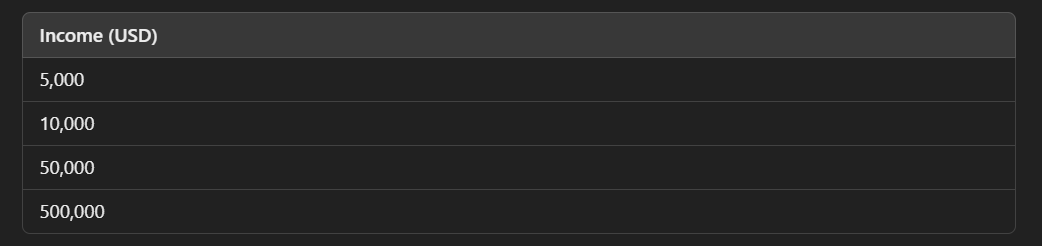

Most values are small, but a few are very large, leading to a right-skewed distribution. Feature transformation techniques can help normalize this distribution.

### Log Transformation
- Used when data is right-skewed.
- Converts skewed data into a more normal distribution.
- Helps when feature values span multiple magnitudes (e.g., income, population).
- Reduces impact of outliers.
- Best for exponential and skewed data.

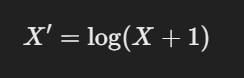

**Example:**
Feature values: [1, 10, 100, 1000]
Log-transformed: [0.69, 2.39, 4.61, 6.91]

**Use Case:**
Used in financial, economic, and biological data where exponential relationships exist.

**When to use:**
- ✅ Income, Population, Sales, or other skewed features
- ✅ Features with extreme values (outliers)

In [2]:
import numpy as np

data = np.array([1, 10, 100, 1000, 10000])
log_transformed = np.log1p(data)  # log1p handles log(0) issue

print(log_transformed)


[0.69314718 2.39789527 4.61512052 6.90875478 9.21044037]


In [4]:
import pandas as pd

# Sample data
data = {'Square_Feet': [500, 1000, 2500, 4000]}
df = pd.DataFrame(data)

df['Square_Feet_Log'] = np.log1p(df['Square_Feet'])  # log1p avoids log(0) errors

df

,Square_Feet,Square_Feet_Log
0,500,6.216606
1,1000,6.908755
2,2500,7.824446
3,4000,8.294300


### Power Transformation (Box-Cox, Yeo-Johnson)
- Used for stabilizing variance and making data normally distributed.
- Box-Cox Transformation is used for positive values only.
- Yeo-Johnson Transformation works for both positive and negative values.

**Use Case:**
Best for datasets with heteroscedasticity (i.e., non-constant variance).

**When to use:**
- ✅ When normality assumption is important (e.g., PCA, regression)
- ✅ When data has positive values (Box-Cox) or mixed values (Yeo-Johnson)



In [7]:
from sklearn.preprocessing import PowerTransformer

data = np.array([[1], [10], [100], [1000], [10000]])
pt = PowerTransformer(method='yeo-johnson')  # Can use 'box-cox' if data > 0
transformed_data = pt.fit_transform(data)

print(transformed_data)


[[-1.37359515]
 [-0.76150032]
 [-0.00726906]
 [ 0.7259013 ]
 [ 1.41646323]]


In [5]:
from sklearn.preprocessing import PowerTransformer

# Box-Cox transformation (only works with positive values)
pt = PowerTransformer(method='box-cox')
df['Square_Feet_BoxCox'] = pt.fit_transform(df[['Square_Feet']])

df

,Square_Feet,Square_Feet_Log,Square_Feet_BoxCox
0,500,6.216606,-1.321160
1,1000,6.908755,-0.545887
2,2500,7.824446,0.606709
3,4000,8.294300,1.260337


### Binning (Discretization)
- Converts continuous variables into categorical groups.
- Helps in handling non-linearity in ML models.
- Useful for converting age, salary, or grades into categories.
    
**Example:**
Age values: [10, 22, 35, 46, 58, 72]

Binned into categories:

- 0-20 → "Young"
- 21-40 → "Adult"
- 41-60 → "Middle-aged"
- 61+ → "Senior"

**Use Case:**
Used in decision trees and rule-based models.

**When to use:**
- ✅ Converting continuous data into categorical bins
- ✅ Handling non-linear relationships

In [8]:
from sklearn.preprocessing import KBinsDiscretizer

data = np.array([[10], [20], [30], [40], [50]])
binner = KBinsDiscretizer(n_bins=3, encode='ordinal', strategy='uniform')
binned_data = binner.fit_transform(data)

print(binned_data)


[[0.]
 [0.]
 [1.]
 [2.]
 [2.]]


In [9]:
df['Size_Category'] = pd.cut(df['Square_Feet'], bins=[0, 1000, 3000, 5000], labels=['Small', 'Medium', 'Large'])

df

,Square_Feet,Square_Feet_Log,Square_Feet_BoxCox,Size_Category
0,500,6.216606,-1.321160,Small
1,1000,6.908755,-0.545887,Small
2,2500,7.824446,0.606709,Medium
3,4000,8.294300,1.260337,Large


### Polynomial Transformation
- Creates higher-degree polynomial features to capture non-linear relationships.

Example:

Original Feature: X=[1,2,3]

Polynomial Features (degree=2): X^2 =[1,4,9]

**Use Case:**
Used in polynomial regression models.

Polynomial Transformation is useful when:

✅ 1. The Relationship Between Features and Target is Non-Linear

    - If a simple linear model is underfitting the data, adding polynomial terms helps capture the curved relationships.

    - Example: If plotting y = f(x) shows a curve instead of a straight line, polynomial features can help.

✅ 2. You Want to Improve Model Performance Without Using Complex Models

    - Instead of using complex models like Random Forest or Neural Networks, you can improve a linear regression model by adding polynomial features.

✅ 3. You Need to Capture Interaction Effects Between Features

    - Polynomial transformation can create new features by multiplying existing features (e.g., x1 * x2, x1², x2²).

    - Useful in regression models where feature interactions matter.

✅ 4. Feature Engineering for Certain ML Models

    - Polynomial features improve performance in linear models, logistic regression, and SVMs with polynomial kernels.

    - Some algorithms (like Decision Trees) don’t need this transformation because they automatically capture non-linearity.



In [10]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
poly_features = poly.fit_transform(df[['Square_Feet']])

df_poly = pd.DataFrame(poly_features, columns=['Square_Feet', 'Square_Feet^2'])
df_poly

,Square_Feet,Square_Feet^2
0,500.0,250000.0
1,1000.0,1000000.0
2,2500.0,6250000.0
3,4000.0,16000000.0


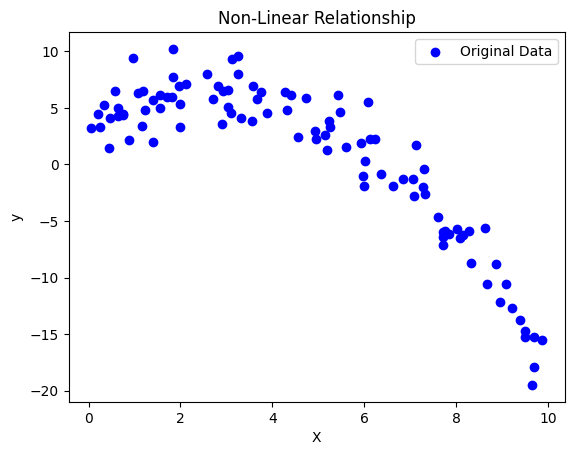

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

# Create sample dataset
np.random.seed(42)
X = np.random.rand(100, 1) * 10  # Random values between 0 and 10
y = 2 + 3 * X - 0.5 * X**2 + np.random.randn(100, 1) * 2  # Quadratic equation with noise

# Plot original data
plt.scatter(X, y, color='blue', label="Original Data")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Non-Linear Relationship")
plt.legend()
plt.show()

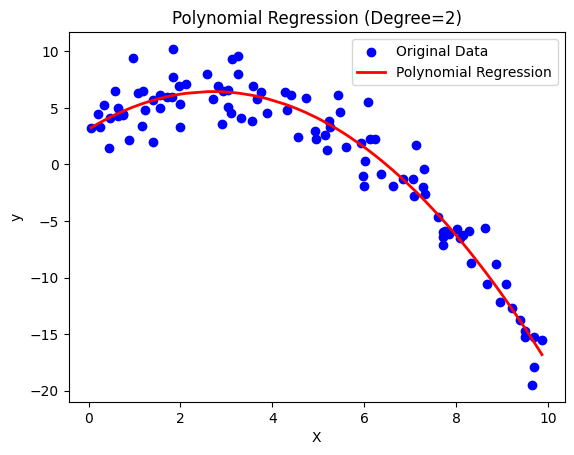

In [15]:
# Create polynomial features (degree 2)
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

# Train a linear regression model on polynomial features
model = LinearRegression()
model.fit(X_poly, y)

# Predict values
X_sorted = np.sort(X, axis=0)
y_pred = model.predict(poly.transform(X_sorted))

# Plot results
plt.scatter(X, y, color='blue', label="Original Data")
plt.plot(X_sorted, y_pred, color='red', linewidth=2, label="Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.title("Polynomial Regression (Degree=2)")
plt.legend()
plt.show()

# ✅ The original data (blue dots) follows a curved trend.
# ✅ A linear model wouldn’t fit well, but using polynomial features (degree=2) improves the model.

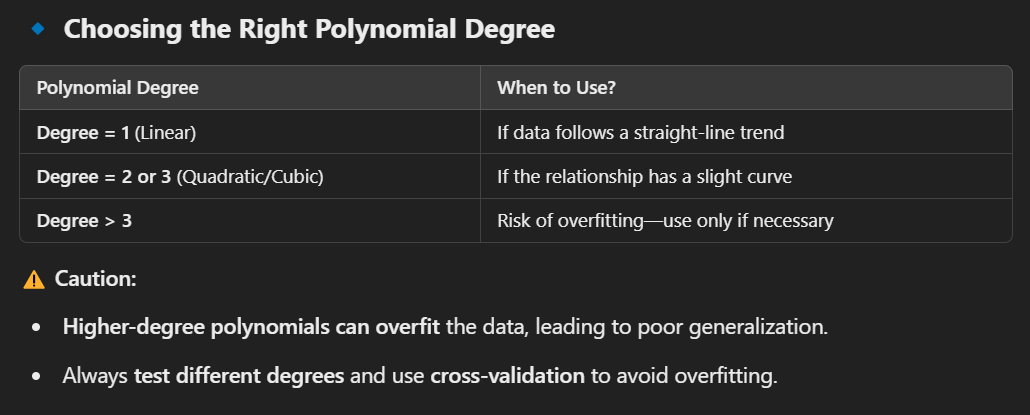

### Square Root and Cube Root Transformation
Used for:

- Handling moderately skewed data
- Reducing impact of large values

In [16]:
data = pd.DataFrame({'Income': [1000, 5000, 10000, 50000, 100000]})

data['Sqrt_Income'] = np.sqrt(data['Income'])
data['Cbrt_Income'] = np.cbrt(data['Income'])
data

,Income,Sqrt_Income,Cbrt_Income
0,1000,31.622777,10.000000
1,5000,70.710678,17.099759
2,10000,100.000000,21.544347
3,50000,223.606798,36.840315
4,100000,316.227766,46.415888


### Quantile Transformation (Uniform or Normal Distribution)
- Maps data to a uniform or normal distribution.
- Useful when data has a complex structure.
- Ensures each value falls into quantiles.

Quantile Transformation is a non-linear transformation that maps the data to a uniform or normal (Gaussian) distribution. This helps in handling skewed and non-Gaussian data, making it more suitable for machine learning models.

**Why Use Quantile Transformation?**

- Makes data more Gaussian-like, improving performance in models that assume normality (e.g., Linear Regression).
- Reduces the impact of outliers.
- Works well for highly skewed data.
- Helps with models that rely on distance metrics (e.g., k-NN, SVM).

**When to use:**
- ✅ When data has outliers and needs normalization
- ✅ For non-Gaussian data to make it Gaussian

**Types of Quantile Transformation**
1. Uniform Transformation (output_distribution='uniform')
    - Transforms data to a uniform distribution in range [0,1].
    - Useful when data is highly skewed and needs even spacing.

2. Normal (Gaussian) Transformation (output_distribution='normal')
    - Transforms data to follow a normal (Gaussian) distribution.
    - Useful for algorithms that assume normality (e.g., Linear Regression, PCA).

Applying Quantile Transformation on the Boston Housing Dataset Let's apply Quantile Transformation on the CRIM (crime rate) column.

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.preprocessing import QuantileTransformer

# Load dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)
df = boston.frame

# Display first 5 rows
df[['CRIM']].head()


,CRIM
0,0.00632
1,0.02731
2,0.02729
3,0.03237
4,0.06905


In [12]:
# Create QuantileTransformer instances
qt_uniform = QuantileTransformer(output_distribution='uniform', random_state=0)
qt_normal = QuantileTransformer(output_distribution='normal', random_state=0)

# Apply transformations
df['CRIM_Quantile_Uniform'] = qt_uniform.fit_transform(df[['CRIM']])
df['CRIM_Quantile_Normal'] = qt_normal.fit_transform(df[['CRIM']])

# Display first 5 rows
df[['CRIM', 'CRIM_Quantile_Uniform', 'CRIM_Quantile_Normal']].head()


e:\notebook\notebook_env\lib\site-packages\sklearn\preprocessing\_data.py:2785: UserWarning: n_quantiles (1000) is greater than the total number of samples (506). n_quantiles is set to n_samples.
  warnings.warn(
e:\notebook\notebook_env\lib\site-packages\sklearn\preprocessing\_data.py:2785: UserWarning: n_quantiles (1000) is greater than the total number of samples (506). n_quantiles is set to n_samples.
  warnings.warn(


,CRIM,CRIM_Quantile_Uniform,CRIM_Quantile_Normal
0,0.00632,0.000000,-5.199338
1,0.02731,0.047525,-1.669343
2,0.02729,0.045545,-1.689680
3,0.03237,0.065347,-1.511374
4,0.06905,0.219802,-0.772862


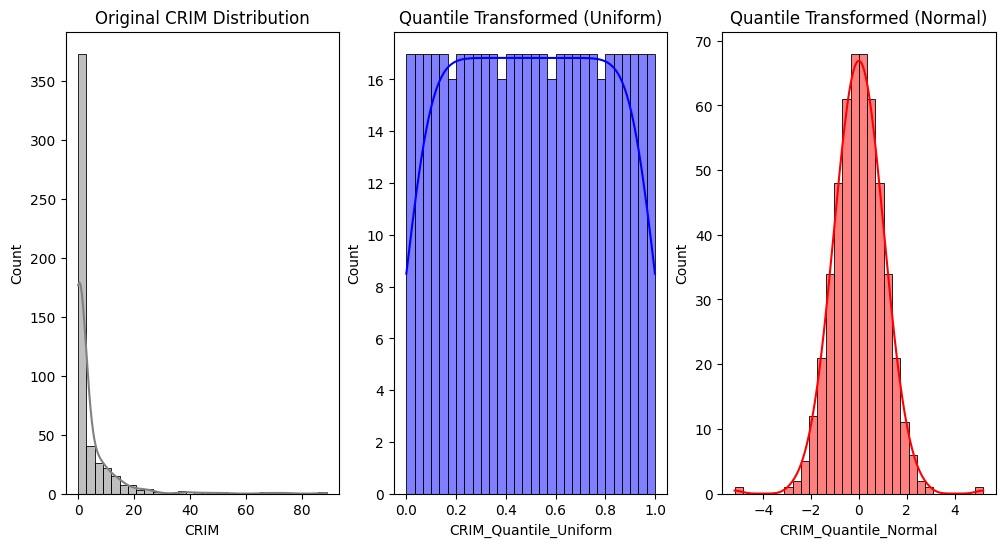

In [13]:
plt.figure(figsize=(12, 6))

# Original Distribution
plt.subplot(1, 3, 1)
sns.histplot(df['CRIM'], bins=30, kde=True, color='gray')
plt.title("Original CRIM Distribution")

# Uniform Quantile Transformation
plt.subplot(1, 3, 2)
sns.histplot(df['CRIM_Quantile_Uniform'], bins=30, kde=True, color='blue')
plt.title("Quantile Transformed (Uniform)")

# Normal Quantile Transformation
plt.subplot(1, 3, 3)
sns.histplot(df['CRIM_Quantile_Normal'], bins=30, kde=True, color='red')
plt.title("Quantile Transformed (Normal)")

plt.show()


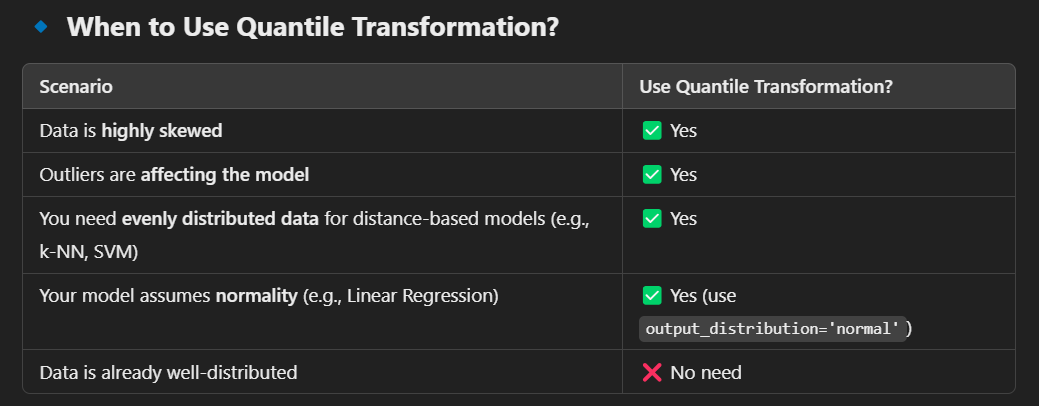

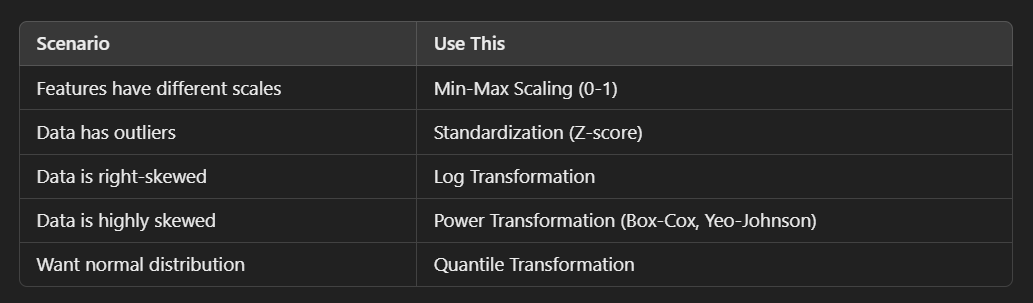

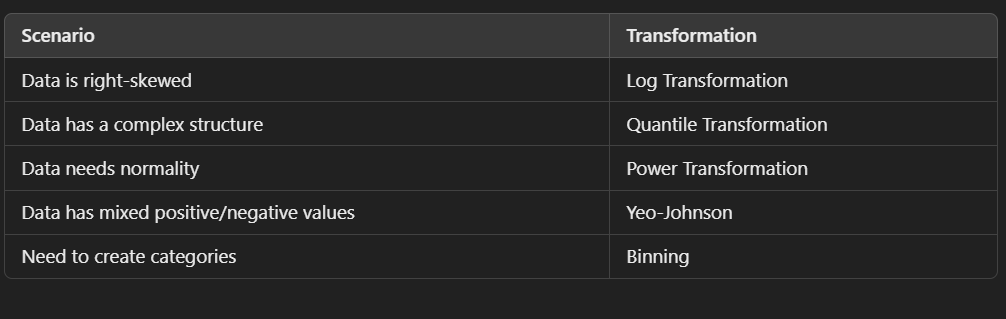

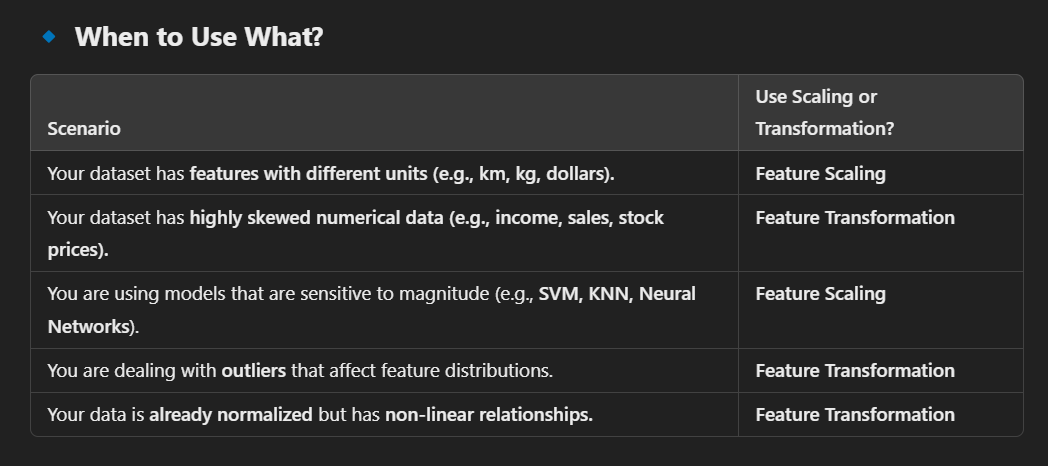

# Categorical data

Handling categorical data is a crucial step in preparing your data for machine learning models, as most machine learning algorithms require numerical input. Here are different ways to handle categorical data:

**One-Hot Encoding (Dummy Variables):**

One-hot encoding is a common method for converting categorical variables into numerical format.

It creates binary columns for each category and assigns a 1 or 0 to indicate the presence or absence of each category.

One-hot encoding is suitable for nominal categorical variables (categories without inherent order).
Example:

<pre>
| Color |
|-------|
| Red   |
| Blue  |
| Green |

After one-hot encoding:
| Color_Red | Color_Blue | Color_Green |
|-----------|------------|-------------|
| 1         | 0          | 0           |
| 0         | 1          | 0           |
| 0         | 0          | 1           |
</pre>

**Label Encoding:**

Label encoding assigns a unique integer value to each category in a categorical variable.

It is suitable for ordinal categorical variables (categories with a specific order).

Be cautious when using label encoding with nominal variables, as it may imply an ordinal relationship that doesn't exist.
Example:

<pre>
| Size   |
|--------|
| Small  |
| Medium |
| Large  |

After label encoding:
| Size  |
|-------|
| 0     |
| 1     |
| 2     |
</pre>

**Frequency Encoding (Count Encoding):**

Frequency encoding replaces each category with its frequency or count in the dataset.

It can capture the importance of each category based on its prevalence in the data.
Example:

<pre>
| Country |
|---------|
| USA     |
| Japan   |
| USA     |
| Germany |
| Japan   |

After frequency encoding:
| Country |
|---------|
| 2       |
| 2       |
| 2       |
| 1       |
| 2       |
</pre>

**Target Encoding (Mean Encoding):**

Target encoding calculates the mean of the target variable for each category and replaces the category with its corresponding mean.

It can be useful when the categorical variable has a strong relationship with the target variable.
Example:

<pre>
| City   | Target |
|--------|--------|
| NYC    | 25     |
| Boston | 20     |
| NYC    | 25     |
| LA     | 18     |
| Boston | 20     |

After target encoding:
| City   | Target |
|--------|--------|
| 23.3   | 23.3   |
| 20.0   | 20.0   |
| 23.3   | 23.3   |
| 19.0   | 19.0   |
| 20.0   | 20.0   |
</pre>

**Binary Encoding:**

Binary encoding converts each category into binary code and creates separate binary columns for each digit in the code.
It can be more efficient than one-hot encoding when dealing with a large number of categories.
Example:

<pre>
| Gender |
|--------|
| Male   |
| Female |
| Male   |
| Other  |

After binary encoding:
| Gender_0 | Gender_1 | Gender_2 |
|----------|----------|----------|
| 0        | 1        | 0        |
| 1        | 0        | 1        |
| 0        | 1        | 0        |
| 1        | 1        | 0        |
</pre>

**Embedding Layers (for Neural Networks):**

In deep learning and neural networks, you can use embedding layers to learn representations of categorical variables.
Embedding layers map each category to a lower-dimensional vector space where relationships between categories can be learned during model training.


These are some common techniques for handling categorical data, and the choice of method depends on the nature of the data and the requirements of your machine learning model. It's essential to select the appropriate method to avoid introducing bias or misrepresenting the information contained in your categorical variables.

In [17]:
# One-Hot Encoding

import pandas as pd

data = pd.DataFrame({'Color': ['Red', 'Blue', 'Green']})

# Use pandas' get_dummies() function for one-hot encoding
one_hot_encoded = pd.get_dummies(data, columns=['Color'])
print(one_hot_encoded)

   Color_Blue  Color_Green  Color_Red
0           0            0          1
1           1            0          0
2           0            1          0


In [2]:
# Label Encoding:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

data = pd.DataFrame({'Size': ['Small', 'Medium', 'Large']})

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Apply label encoding to the 'Size' column
data['Size_encoded'] = label_encoder.fit_transform(data['Size'])
data

,Size,Size_encoded
0,Small,2
1,Medium,1
2,Large,0


In [19]:
# Frequency Encoding (Count Encoding):

data = pd.DataFrame({'Country': ['USA', 'Japan', 'USA', 'Germany', 'Japan']})

# Use value_counts() to create a frequency encoding dictionary
frequency_encoding = data['Country'].value_counts().to_dict()

# Map the frequency encoding to the 'Country' column
data['Country_encoded'] = data['Country'].map(frequency_encoding)
print(data)

   Country  Country_encoded
0      USA                2
1    Japan                2
2      USA                2
3  Germany                1
4    Japan                2


In [20]:
# Target Encoding (Mean Encoding):

data = pd.DataFrame({'City': ['NYC', 'Boston', 'NYC', 'LA', 'Boston'], 'Target': [25, 20, 25, 18, 20]})

# Calculate the mean encoding for each category in 'City'
mean_encoding = data.groupby('City')['Target'].mean().to_dict()

# Map the mean encoding to the 'City' column
data['City_encoded'] = data['City'].map(mean_encoding)
print(data)

     City  Target  City_encoded
0     NYC      25          25.0
1  Boston      20          20.0
2     NYC      25          25.0
3      LA      18          18.0
4  Boston      20          20.0


In [23]:
# Binary Encoding:

import category_encoders as ce

data = pd.DataFrame({'Gender': ['Male', 'Female', 'Male', 'Other']})

# Initialize BinaryEncoder
binary_encoder = ce.BinaryEncoder(cols=['Gender'])

# Apply binary encoding to the 'Gender' column
binary_encoded = binary_encoder.fit_transform(data)
print(binary_encoded)

   Gender_0  Gender_1
0         0         1
1         1         0
2         0         1
3         1         1


https://medium.com/geekculture/how-to-handle-categorical-variables-7c1ee198c55c#id_token=eyJhbGciOiJSUzI1NiIsImtpZCI6IjZmNzI1NDEwMWY1NmU0MWNmMzVjOTkyNmRlODRhMmQ1NTJiNGM2ZjEiLCJ0eXAiOiJKV1QifQ.eyJpc3MiOiJodHRwczovL2FjY291bnRzLmdvb2dsZS5jb20iLCJhenAiOiIyMTYyOTYwMzU4MzQtazFrNnFlMDYwczJ0cDJhMmphbTRsamRjbXMwMHN0dGcuYXBwcy5nb29nbGV1c2VyY29udGVudC5jb20iLCJhdWQiOiIyMTYyOTYwMzU4MzQtazFrNnFlMDYwczJ0cDJhMmphbTRsamRjbXMwMHN0dGcuYXBwcy5nb29nbGV1c2VyY29udGVudC5jb20iLCJzdWIiOiIxMDU4NjAxMzc4MDc0MzU5MDI0NDUiLCJlbWFpbCI6InNhdXJhYmhwODUwNzBAZ21haWwuY29tIiwiZW1haWxfdmVyaWZpZWQiOnRydWUsIm5iZiI6MTY5NTQwMjE2MiwibmFtZSI6IlNhdXJhYmggUHJha2FzaCIsInBpY3R1cmUiOiJodHRwczovL2xoMy5nb29nbGV1c2VyY29udGVudC5jb20vYS9BQ2c4b2NJWnlscWwwRWxBRWxNcDFHVUl2VndKUDUyUjQzY0RuRUc0Q3BsS3JEYi1tQT1zOTYtYyIsImdpdmVuX25hbWUiOiJTYXVyYWJoIiwiZmFtaWx5X25hbWUiOiJQcmFrYXNoIiwibG9jYWxlIjoiZW4iLCJpYXQiOjE2OTU0MDI0NjIsImV4cCI6MTY5NTQwNjA2MiwianRpIjoiNmJjYTQ0M2RlYTM5MzAwODJlYWFjODRkYzliYjM1MzMzMzdjM2E0ZiJ9.eE2DQPbFgl8bhqgO6cV0a2GUP3ER0M_X7v6ff3AS9CByrK8NxF5Ov4aP925uYw4n9kC_QKnqT6g8Ay60aOvJx6IoXtA7w-nEU2WT56W5VT-7Cf0h_6W8uwv-64kjb8y8BtoNcoV75SAI5Qaf-N8iOGqr08DgXS9ilxgfaoOuByh_gWzWVxu5sZ-qyBT5m5oOIca0-zRKe3f0yKmU7dTV6Ax06npdwF22vJAvlxcaczMmiiueckL-500z5JUlmWDGHqdz16qn3sxMQe1KasrDvdGDBur9DIohgUdo2Onritu-E4VlUMKHxFnU-2OmhQcBTKXF4I79zJYfzcuzPtmOyA



https://medium.com/big-data-center-of-excellence/how-to-handle-categorical-values-byaryan-a769b2bb4361

https://towardsdatascience.com/handling-categorical-data-the-right-way-9d1279956fc6

https://www.datacamp.com/tutorial/categorical-data

https://dev.to/anurag629/transforming-categorical-data-a-practical-guide-to-handling-non-numerical-variables-for-machine-learning-algorithms-cld

**Handling categorical data can be done both before and after data visualization, and the choice depends on your specific goals and the nature of your data. Here are some considerations for when to handle categorical data in relation to data visualization:**

1. Before Data Visualization:

Data Preparation: It's common to handle categorical data before visualization as part of the data preprocessing step. This includes tasks like one-hot encoding, label encoding, or any other method to convert categorical variables into a numerical format.

Visualization Clarity: By preprocessing categorical data before visualization, you can create visualizations that are more interpretable and informative. For example, one-hot encoding can make it easier to create bar charts or other plots that show the distribution of categories.

Dimension Reduction: Some visualization techniques may require dimensionality reduction methods like Principal Component Analysis (PCA) or t-SNE. Handling categorical data before such techniques can be necessary to avoid issues associated with mixed data types.

Data Exploration: Categorical encoding can help you understand the relationships between categorical variables and the target variable or among themselves, which can guide the choice of visualizations.

2. After Data Visualization:

Exploratory Data Analysis (EDA): In some cases, you might initially perform data visualization to explore the dataset and understand the relationships between variables. After EDA, you can decide how to handle categorical data based on insights gained from visualizations.

Visualization for Encoding Choices: Visualization can help you make informed decisions about how to encode categorical variables. For example, you may discover that one-hot encoding is appropriate for variables with few unique categories, while other encoding methods may be better suited for variables with many categories.

Visualizing Encoding Impact: You might want to visualize the impact of different encoding methods on your data, such as comparing the distribution of a target variable before and after encoding.

In summary, there is no strict rule about whether to handle categorical data before or after data visualization. The choice depends on your analysis workflow and objectives. However, it's common to start with some data preprocessing before visualization to ensure that the visualizations accurately represent the data and that you can derive meaningful insights from them. Subsequent visualizations may then inform further data preprocessing decisions. Ultimately, the goal is to strike a balance between data preparation and exploration to gain a deep understanding of your dataset.

**When you have a dataset that contains a mix of categorical and numerical features, and you want to apply feature scaling to the numerical features, a common approach is to use a combination of techniques, such as one-hot encoding for categorical features and feature scaling for numerical features. Here's a step-by-step approach:**

Identify Categorical and Numerical Features:

Start by identifying which features in your dataset are categorical (nominal or ordinal) and which are numerical (continuous or discrete).
Preprocess Categorical Features (One-Hot Encoding):

For categorical features, you can use one-hot encoding to convert them into a numerical format that machine learning algorithms can work with.
One-hot encoding creates binary columns for each category within a categorical feature. Each binary column represents the presence or absence of a category for a particular data point.
Example: If you have a "Color" feature with categories ["Red", "Green", "Blue"], one-hot encoding would create three binary columns, one for each color.
Preprocess Numerical Features (Feature Scaling):

For numerical features, it's a good practice to apply feature scaling to ensure that all numerical features have a similar scale. Common scaling techniques include:
Standardization (Z-score scaling): Scales the data to have a mean of 0 and a standard deviation of 1. It's suitable for features that are approximately normally distributed.
Min-Max Scaling (Normalization): Scales the data to a specific range, typically between 0 and 1. It's suitable when the feature distribution does not follow a normal distribution and you want to preserve the original data's relationships.
Robust Scaling: Scales data based on the median and interquartile range, making it robust to outliers.
Concatenate Scaled Numerical Features and Encoded Categorical Features:

After scaling the numerical features and one-hot encoding the categorical features, you can concatenate these processed features into a single feature matrix.
Model Training and Evaluation:

You can now use this processed dataset for training your machine learning model. Ensure that you split your data into training and testing sets for model evaluation.
Here's an example of how you can implement this approach using Python and libraries like Pandas and Scikit-Learn:

In [ ]:
# Pseudo code


import pandas as pd
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Load your dataset into a Pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Identify categorical and numerical features
categorical_features = ['Category1', 'Category2']
numerical_features = ['Numerical1', 'Numerical2']

# Create transformers for preprocessing
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # You can use other scalers as needed
])

# Combine transformers using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', categorical_transformer, categorical_features),
        ('num', numerical_transformer, numerical_features)
    ])

# Define your model and combine it with preprocessing using a Pipeline

# Split data into training and testing sets
X = df.drop('target_column', axis=1)
y = df['target_column']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the preprocessing and model on the training data
model.fit(X_train, y_train)

# Evaluate the model on the testing data
score = model.score(X_test, y_test)


we used `Pipeline()` and `ColumnTransformer()` for structured and efficient data preprocessing. Here's why each of these tools is valuable:

`Pipeline()`:

- A Pipeline is a way to streamline a lot of the routine processes by combining multiple data preprocessing steps and a machine learning model into a single, easy-to-use object.
- It helps ensure that the steps of data preprocessing are applied in the correct order. In machine learning workflows, it's common to first preprocess data (e.g., scaling and encoding) and then apply a model. A Pipeline enforces this sequence.
- It simplifies the code and reduces the risk of data leakage. For example, when you scale your data, you should fit the scaler on the training data and then transform both the training and testing data. A Pipeline automates this process.
- Makes it easier to cross-validate your model. When using cross-validation techniques, a Pipeline ensures that preprocessing steps are applied consistently to each fold of the data.

`ColumnTransformer()`:

- A ColumnTransformer is particularly useful when you have a dataset with different types of features (e.g., categorical and numerical) that require different preprocessing techniques.
- It allows you to apply different preprocessing pipelines to different subsets of columns in your dataset.
- In the example given, we used ColumnTransformer to apply one-hot encoding to the categorical features and standard scaling to the numerical features.
- This approach keeps the code organized and makes it clear which preprocessing steps apply to which types of features.

In summary, using Pipeline and ColumnTransformer together offers a structured and efficient way to preprocess data with multiple feature types, ensuring that the correct transformations are applied to each feature subset while simplifying the code and making it more maintainable. This is especially helpful in machine learning workflows where consistency and repeatability are essential.

**You can certainly use an approach where you first separate the categorical and numerical features into two dataframes, apply feature scaling to the numerical dataframe (df2), and one-hot encoding to the categorical dataframe (df1). Afterward, you can combine them back into a single dataframe (df) for model training and evaluation. This approach can be conceptually easier to follow and maintain.**

Here's how you can implement this approach:

In [ ]:
# Pseudo code

import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

# Load your dataset into a Pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Identify categorical and numerical features
categorical_features = ['Category1', 'Category2']
numerical_features = ['Numerical1', 'Numerical2']

# Create dataframes for categorical and numerical features
df1 = df[categorical_features]
df2 = df[numerical_features]

# Apply preprocessing to df1 (categorical features)
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])
df1_processed = categorical_transformer.fit_transform(df1)

# Apply preprocessing to df2 (numerical features)
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())  # You can use other scalers as needed
])
df2_processed = numerical_transformer.fit_transform(df2)

# Combine df1 and df2 back into a single dataframe (df)
df_processed = pd.concat([pd.DataFrame(df1_processed.toarray()), pd.DataFrame(df2_processed, columns=numerical_features)], axis=1)

# Define your model and combine it with preprocessing using a Pipeline

# Split data into training and testing sets
X = df_processed
y = df['target_column']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the preprocessing and model on the training data
model.fit(X_train, y_train)

# Evaluate the model on the testing data
score = model.score(X_test, y_test)


**Certainly, you can achieve the same preprocessing without using Pipeline and keep it simple. You can separately apply feature scaling to numerical features and one-hot encoding to categorical features, and then combine them into a single dataframe. Here's how you can do it:**

In [ ]:
# Pseudo code

import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split

# Load your dataset into a Pandas DataFrame
# df = pd.read_csv('your_dataset.csv')

# Identify categorical and numerical features
categorical_features = ['Category1', 'Category2']
numerical_features = ['Numerical1', 'Numerical2']

# Create dataframes for categorical and numerical features
df1 = df[categorical_features]
df2 = df[numerical_features]

# Apply one-hot encoding to df1 (categorical features)
encoder = OneHotEncoder(handle_unknown='ignore')
df1_encoded = encoder.fit_transform(df1)

# Apply feature scaling to df2 (numerical features)
scaler = StandardScaler()
df2_scaled = scaler.fit_transform(df2)

# Combine df1_encoded and df2_scaled back into a single dataframe (df)
df_processed = pd.concat([pd.DataFrame(df1_encoded.toarray()), pd.DataFrame(df2_scaled, columns=numerical_features)], axis=1)

# Define your model and use df_processed for training and evaluation

# Split data into training and testing sets
X = df_processed
y = df['target_column']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Fit the model on the training data
model.fit(X_train, y_train)

# Evaluate the model on the testing data
score = model.score(X_test, y_test)


**The choice between using a Pipeline or not depends on your specific needs, preferences, and the complexity of your data preprocessing workflow. Both approaches are valid and have their advantages and disadvantages:**

`With Pipeline`:

Advantages:

- Structured Workflow: Using a Pipeline enforces a structured and sequential workflow for data preprocessing. This can make your code more organized and easier to follow.

- Data Leakage Prevention: A Pipeline helps prevent data leakage by ensuring that preprocessing steps are applied consistently to both the training and testing datasets.

- Cross-Validation: When using cross-validation techniques, a Pipeline ensures that preprocessing is part of each fold, making cross-validation results more reliable.

- Reusability: Pipelines are reusable components. Once you define a pipeline, you can use it on different datasets or with different models with minimal code changes.

Disadvantages:

- Complexity: For simple preprocessing tasks, a Pipeline might be overkill and add unnecessary complexity to your code.

`Without Pipeline`:

Advantages:

- Simplicity: Without a Pipeline, your code can be simpler and easier to understand, especially for straightforward preprocessing tasks.

- Control: You have more fine-grained control over each preprocessing step, which can be beneficial if you need to customize or modify individual steps.

- Transparency: It's easier to see and modify each preprocessing step separately.

Disadvantages:

- Potential for Data Leakage: Without a Pipeline, you must be careful to apply preprocessing consistently to both training and testing data to avoid data leakage.

- Maintenance: As your preprocessing steps grow more complex, the code may become harder to maintain and extend.

In conclusion, the best approach depends on the complexity of your data and your specific requirements. For simple preprocessing tasks, a straightforward approach without a Pipeline can be more concise and easier to work with. However, for more complex workflows, or when working on projects where data consistency and reproducibility are critical, using a Pipeline is often recommended. Ultimately, the choice between the two approaches should align with the goals of your data preprocessing and modeling tasks.

# Statisitical Analysis  

- Statistical analysis involves the collection, organization, analysis, interpretation, and presentation of data. 
- It aims to uncover patterns, trends, relationships, and insights within the data. 
- Statistical analysis employs various statistical techniques and methods to summarize and describe data, make inferences about populations based on samples, and test hypotheses. 
- It provides a framework for making informed decisions and predictions based on data evidence. 
- Statistical analysis is crucial in extracting meaningful information from data and understanding the underlying phenomena.

# Statistical modelling

- Statistical modeling is a process of building mathematical models to represent and understand the relationships between variables in data. 
- These models are constructed based on statistical principles and techniques. 
- Statistical models can be descriptive, predictive, or inferential in nature. 
        - Descriptive models summarize the characteristics of data. 
        - Predictive models aim to forecast or estimate future outcomes. 
        - Inferential models are used to make inferences or draw conclusions about populations based on sample data. 
- Statistical modeling involves selecting an appropriate model, estimating model parameters from data, evaluating model performance, and making interpretations or predictions based on the model results. 
- It plays a fundamental role in various fields such as economics, finance, biology, social sciences, and many others, providing insights into complex phenomena and aiding decision-making processes.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

In [2]:
X

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

In [3]:
y

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2])

In [4]:
feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

In [5]:
# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled

array([[-9.00681170e-01,  1.01900435e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00, -1.31979479e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.38535265e+00,  3.28414053e-01, -1.39706395e+00,
        -1.31544430e+00],
       [-1.50652052e+00,  9.82172869e-02, -1.28338910e+00,
        -1.31544430e+00],
       [-1.02184904e+00,  1.24920112e+00, -1.34022653e+00,
        -1.31544430e+00],
       [-5.37177559e-01,  1.93979142e+00, -1.16971425e+00,
        -1.05217993e+00],
       [-1.50652052e+00,  7.88807586e-01, -1.34022653e+00,
        -1.18381211e+00],
       [-1.02184904e+00,  7.88807586e-01, -1.28338910e+00,
        -1.31544430e+00],
       [-1.74885626e+00, -3.62176246e-01, -1.34022653e+00,
        -1.31544430e+00],
       [-1.14301691e+00,  9.82172869e-02, -1.28338910e+00,
        -1.44707648e+00],
       [-5.37177559e-01,  1.47939788e+00, -1.28338910e+00,
        -1.31544430e+00],
       [-1.26418478e+00,  7.88807586e-01, -1.22655167e+00,
      

In [6]:
# Perform PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-2.26470281,  0.4800266 ],
       [-2.08096115, -0.67413356],
       [-2.36422905, -0.34190802],
       [-2.29938422, -0.59739451],
       [-2.38984217,  0.64683538],
       [-2.07563095,  1.48917752],
       [-2.44402884,  0.0476442 ],
       [-2.23284716,  0.22314807],
       [-2.33464048, -1.11532768],
       [-2.18432817, -0.46901356],
       [-2.1663101 ,  1.04369065],
       [-2.32613087,  0.13307834],
       [-2.2184509 , -0.72867617],
       [-2.6331007 , -0.96150673],
       [-2.1987406 ,  1.86005711],
       [-2.26221453,  2.68628449],
       [-2.2075877 ,  1.48360936],
       [-2.19034951,  0.48883832],
       [-1.898572  ,  1.40501879],
       [-2.34336905,  1.12784938],
       [-1.914323  ,  0.40885571],
       [-2.20701284,  0.92412143],
       [-2.7743447 ,  0.45834367],
       [-1.81866953,  0.08555853],
       [-2.22716331,  0.13725446],
       [-1.95184633, -0.62561859],
       [-2.05115137,  0.24216355],
       [-2.16857717,  0.52714953],
       [-2.13956345,

In [8]:
# Create a DataFrame for the PCA results
pca_df = pd.DataFrame(data=X_pca, columns=['PC1', 'PC2'])
pca_df['Target'] = y
pca_df

,PC1,PC2,Target
0,-2.264703,0.480027,0
1,-2.080961,-0.674134,0
2,-2.364229,-0.341908,0
3,-2.299384,-0.597395,0
4,-2.389842,0.646835,0
...,...,...,...
145,1.870503,0.386966,2
146,1.564580,-0.896687,2
147,1.521170,0.269069,2
148,1.372788,1.011254,2


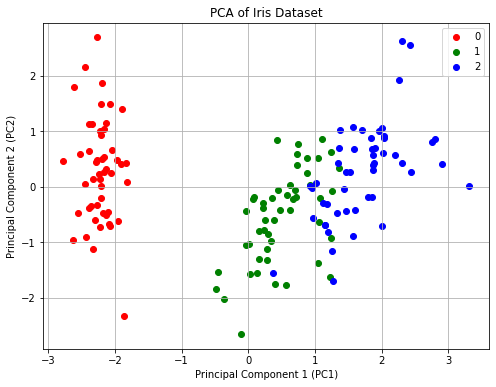

Explained Variance Ratio: [0.72962445 0.22850762]


In [9]:
# Visualize the PCA results
plt.figure(figsize=(8, 6))
targets = np.unique(y)
colors = ['r', 'g', 'b']
for target, color in zip(targets, colors):
    indices_to_keep = pca_df['Target'] == target
    plt.scatter(pca_df.loc[indices_to_keep, 'PC1'],
                pca_df.loc[indices_to_keep, 'PC2'],
                c=color,
                label=target)
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.title('PCA of Iris Dataset')
plt.legend(targets)
plt.grid(True)
plt.show()

# Explained variance ratio
print("Explained Variance Ratio:", pca.explained_variance_ratio_)
